In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold

from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

%matplotlib inline

In [4]:
df = pd.read_csv('https://github.com/alexeygrigorev/datasets/raw/refs/heads/master/jamb_exam_results.csv')

In [5]:
df.columns = df.columns.str.lower().str.replace(' ', '_')

In [6]:
df.head()

,jamb_score,study_hours_per_week,attendance_rate,teacher_quality,distance_to_school,school_type,school_location,extra_tutorials,access_to_learning_materials,parent_involvement,it_knowledge,student_id,age,gender,socioeconomic_status,parent_education_level,assignments_completed
0,192,22,78,4,12.4,Public,Urban,Yes,Yes,High,Medium,1,17,Male,Low,Tertiary,2
1,207,14,88,4,2.7,Public,Rural,No,Yes,High,High,2,15,Male,High,NaN,1
2,182,29,87,2,9.6,Public,Rural,Yes,Yes,High,Medium,3,20,Female,High,Tertiary,2
3,210,29,99,2,2.6,Public,Urban,No,Yes,Medium,High,4,22,Female,Medium,Tertiary,1
4,199,12,98,3,8.8,Public,Urban,No,Yes,Medium,Medium,5,22,Female,Medium,Tertiary,1


In [7]:
del df['student_id']

In [8]:
df = df.fillna(0)
df.isnull().sum()

jamb_score                      0
study_hours_per_week            0
attendance_rate                 0
teacher_quality                 0
distance_to_school              0
school_type                     0
school_location                 0
extra_tutorials                 0
access_to_learning_materials    0
parent_involvement              0
it_knowledge                    0
age                             0
gender                          0
socioeconomic_status            0
parent_education_level          0
assignments_completed           0
dtype: int64

In [9]:
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=1)
len(df_train), len(df_val), len(df_test)

(3000, 1000, 1000)

In [10]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [11]:
y_train = df_train.jamb_score.values
y_val = df_val.jamb_score.values
y_test = df_test.jamb_score.values

In [12]:
del df_train['jamb_score']
del df_val['jamb_score']
del df_test['jamb_score']

#### Question 1

Let's train a decision tree regressor to predict the jamb_score variable.
- Train a model with max_depth=1.

Which feature is used for splitting the data?

In [13]:
from sklearn.tree import DecisionTreeRegressor

In [14]:
def train(df_train, y_train, max_depth=1):
    dicts = df_train.to_dict(orient='records')

    dv = DictVectorizer(sparse=False)
    X_train = dv.fit_transform(dicts)

    dt = DecisionTreeRegressor(max_depth=max_depth)
    dt.fit(X_train, y_train)

    return dv, dt

In [15]:
def predict(df, dv, model):
    dicts = df.to_dict(orient='records')

    X = dv.transform(dicts)
    y_pred = model.predict(X)

    return y_pred

In [16]:
dv, model = train(df_train, y_train)

In [17]:
y_pred = predict(df_val, dv, model)

In [18]:
len(y_pred)

1000

In [19]:
from sklearn.tree import export_text

In [20]:
print(export_text(model, feature_names=dv.get_feature_names_out()))

|--- study_hours_per_week <= 18.50
|   |--- value: [155.24]
|--- study_hours_per_week >  18.50
|   |--- value: [188.59]



#### Question 2

Train a random forest regressor with these parameters:
- n_estimators=10
- random_state=1
- n_jobs=-1 (optional - to make training faster)

What's the RMSE of this model on the validation data?

In [21]:
from sklearn.ensemble import RandomForestRegressor

In [22]:
def rf_train(df_train, y_train, n_estimators=10):
    dicts = df_train.to_dict(orient='records')

    dv = DictVectorizer(sparse=False)
    X_train = dv.fit_transform(dicts)

    rf = RandomForestRegressor(n_estimators=n_estimators, random_state=1, n_jobs=-1)
    rf.fit(X_train, y_train)

    return dv, rf

In [23]:
def rf_predict(df, dv, model):
    dicts = df.to_dict(orient='records')

    X = dv.transform(dicts)
    y_pred = model.predict(X)

    return y_pred

In [24]:
dv, model = rf_train(df_train, y_train)

In [25]:
y_pred = rf_predict(df_val, dv, model)

In [26]:
def rmse(y, y_pred):
    error = y - y_pred
    se = error ** 2
    mse = se.mean()
    return np.sqrt(mse)

In [27]:
rmse_value = rmse(y_val, y_pred)
print(f"RMSE is: {round(rmse_value,2)}")

RMSE is: 42.14


#### Question 3

Now let's experiment with the n_estimators parameter
- Try different values of this parameter from 10 to 200 with step 10.
- Set random_state to 1.
- Evaluate the model on the validation dataset.

After which value of n_estimators does RMSE stop improving? Consider 3 decimal places for calculating the answer.

In [28]:
estimators = np.arange(10, 210, 10)

In [29]:
rmse_scores = []
for n in estimators:
    dv, model = rf_train(df_train, y_train, n_estimators=n)
    y_pred = rf_predict(df_val, dv, model)
    rmse_scores.append((n, round(rmse(y_val, y_pred),3)))

rmse_scores

[(10, 42.137),
 (20, 41.461),
 (30, 41.106),
 (40, 40.917),
 (50, 40.852),
 (60, 40.784),
 (70, 40.677),
 (80, 40.539),
 (90, 40.504),
 (100, 40.517),
 (110, 40.593),
 (120, 40.625),
 (130, 40.651),
 (140, 40.595),
 (150, 40.597),
 (160, 40.604),
 (170, 40.628),
 (180, 40.641),
 (190, 40.631),
 (200, 40.601)]

#### Question 4

Let's select the best max_depth:
- Try different values of max_depth: [10, 15, 20, 25]
- For each of these values,
    - try different values of n_estimators from 10 till 200 (with step 10)
    - calculate the mean RMSE
- Fix the random seed: random_state=1

What's the best max_depth, using the mean RMSE?

In [30]:
depth = [10, 15, 20, 25]

In [31]:
def d_n_rf_train(df_train, y_train, n_estimators=10, max_depth=10):
    dicts = df_train.to_dict(orient='records')

    dv = DictVectorizer(sparse=False)
    X_train = dv.fit_transform(dicts)

    rf = RandomForestRegressor(n_estimators=n_estimators, max_depth=max_depth, random_state=1, n_jobs=-1)
    rf.fit(X_train, y_train)

    return dv, rf

In [32]:
scores = []

for d in depth:
    for n in estimators:
        dv, model = d_n_rf_train(df_train, y_train, n_estimators=n, max_depth=d)
        y_pred = rf_predict(df_val, dv, model)
        scores.append((d, n, round(rmse(y_val, y_pred),3)))

In [33]:
columns = ['max_depth', 'n_estimators', 'rmse']
df_scores = pd.DataFrame(scores, columns=columns)
df_scores.head()

,max_depth,n_estimators,rmse
0,10,10,41.258
1,10,20,40.881
2,10,30,40.625
3,10,40,40.270
4,10,50,40.317


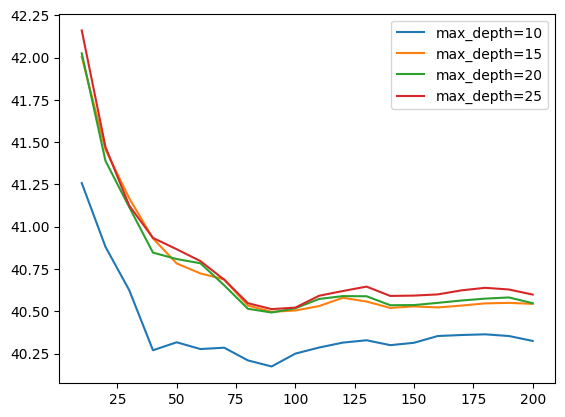

In [34]:
for d in depth:
    df_subset = df_scores[df_scores.max_depth == d]
    plt.plot(df_subset.n_estimators, df_subset.rmse, label='max_depth=%d' %d)
plt.legend()

#### Question 5

We can extract feature importance information from tree-based models. At each step of the decision tree learning algorithm, it finds the best split. When doing it, we can calculate "gain" - the reduction in impurity before and after the split. This gain is quite useful in understanding what are the important features for tree-based models. In Scikit-Learn, tree-based models contain this information in the feature_importances_ field.

For this homework question, we'll find the most important feature:
- Train the model with these parameters:
    - n_estimators=10,
    - max_depth=20,
    - random_state=1,
    - n_jobs=-1 (optional)
- Get the feature importance information from this model

What's the most important feature (among these 4)?

In [35]:
dv, model = d_n_rf_train(df_train, y_train, n_estimators=10, max_depth=20)
model.feature_importances_

array([0.0123254 , 0.01026189, 0.06931145, 0.03151679, 0.14972903,
       0.1364858 , 0.01345934, 0.00913136, 0.00928871, 0.01038263,
       0.01771934, 0.01240405, 0.00914148, 0.        , 0.01545036,
       0.01695692, 0.01448862, 0.02291885, 0.01335761, 0.01149201,
       0.00955909, 0.00923932, 0.0089532 , 0.00840598, 0.02571426,
       0.01070798, 0.01056268, 0.24835361, 0.08268222])

In [36]:
dv.get_feature_names_out()

array(['access_to_learning_materials=No',
       'access_to_learning_materials=Yes', 'age', 'assignments_completed',
       'attendance_rate', 'distance_to_school', 'extra_tutorials=No',
       'extra_tutorials=Yes', 'gender=Female', 'gender=Male',
       'it_knowledge=High', 'it_knowledge=Low', 'it_knowledge=Medium',
       'parent_education_level', 'parent_education_level=Primary',
       'parent_education_level=Secondary',
       'parent_education_level=Tertiary', 'parent_involvement=High',
       'parent_involvement=Low', 'parent_involvement=Medium',
       'school_location=Rural', 'school_location=Urban',
       'school_type=Private', 'school_type=Public',
       'socioeconomic_status=High', 'socioeconomic_status=Low',
       'socioeconomic_status=Medium', 'study_hours_per_week',
       'teacher_quality'], dtype=object)

In [37]:
ft_importances = []

for f in range(len(model.feature_importances_)):
    ft_importances.append((dv.get_feature_names_out()[f], model.feature_importances_[f]))
np.sort(ft_importances, axis=0)[::-1]

array([['teacher_quality', '0.24835361199396536'],
       ['study_hours_per_week', '0.1497290297846747'],
       ['socioeconomic_status=Medium', '0.1364858048632369'],
       ['socioeconomic_status=Low', '0.0826822226388016'],
       ['socioeconomic_status=High', '0.06931145469695398'],
       ['school_type=Public', '0.03151678945460071'],
       ['school_type=Private', '0.025714264343587142'],
       ['school_location=Urban', '0.022918852929064194'],
       ['school_location=Rural', '0.0177193420394119'],
       ['parent_involvement=Medium', '0.016956919815100068'],
       ['parent_involvement=Low', '0.01545036018792814'],
       ['parent_involvement=High', '0.014488617277194148'],
       ['parent_education_level=Tertiary', '0.013459336291731934'],
       ['parent_education_level=Secondary', '0.013357613537934167'],
       ['parent_education_level=Primary', '0.012404050525957137'],
       ['parent_education_level', '0.012325395818561702'],
       ['it_knowledge=Medium', '0.01149201164

#### Question 6

Now let's train an XGBoost model! For this question, we'll tune the eta parameter:
- Install XGBoost
- Create DMatrix for train and validation
- Create a watchlist
- Train a model with these parameters for 100 rounds:
    - xgb_params = {
        - 'eta': 0.3, 
        - 'max_depth': 6,
        - 'min_child_weight': 1,
        - 'objective': 'reg:squarederror',
        - 'nthread': 8,
        - 'seed': 1,
        - 'verbosity': 1,
      }
- Now change eta from 0.3 to 0.1.

Which eta leads to the best RMSE score on the validation dataset?

In [1]:
import sys
!{sys.executable} -m pip install xgboost

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 14.0 MB/s eta 0:00:00m eta 0:00:010:01


In [2]:
import xgboost as xgb

In [38]:
train_dicts = df_train.to_dict(orient='records')
val_dicts = df_val.to_dict(orient='records')
dv = DictVectorizer(sparse=False)
X_train = dv.fit_transform(train_dicts)
X_val = dv.transform(val_dicts)

In [42]:
features = dv.get_feature_names_out().tolist()
dtrain = xgb.DMatrix(X_train, label=y_train, feature_names=features)
dval = xgb.DMatrix(X_val, label=y_val, feature_names=features)

In [44]:
xgb_params = {
    'eta': 0.3,
    'max_depth': 6,
    'min_child_weight': 1,
    'objective': 'reg:squarederror',
    'nthread': 8,
    'seed': 1,
    'verbosity': 1,
}
model = xgb.train(xgb_params, dtrain, num_boost_round=100)

In [45]:
y_pred = model.predict(dval)

In [47]:
rmse(y_val, y_pred)

44.432098039002526

In [48]:
xgb_params = {
    'eta': 0.1,
    'max_depth': 6,
    'min_child_weight': 1,
    'objective': 'reg:squarederror',
    'nthread': 8,
    'seed': 1,
    'verbosity': 1,
}
model = xgb.train(xgb_params, dtrain, num_boost_round=100)
y_pred = model.predict(dval)
rmse(y_val, y_pred)

41.043354592351655